In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Exercício 1

<Axes: ylabel='Count'>

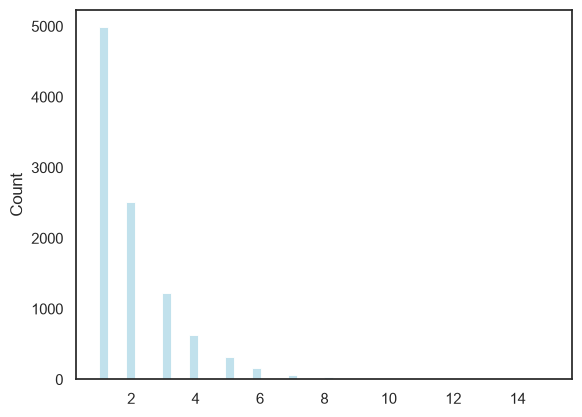

In [92]:
### Distribuição Geométrica: jogar moedas até obter cara
M = 10000

def Geo_Ing(M,p):
    Geom = []
    for i in range(M):
        p = 0.5
        x = 1
        B = np.random.uniform(0,1) < p
        while B!=1:
            x = x + 1
            B = np.random.uniform(0,1) < p
        Geom.append(x)
    return Geom


teste = Geo_Ing(M,0.3)
sns.histplot(teste, bins = 50, color='lightblue')


<Axes: ylabel='Count'>

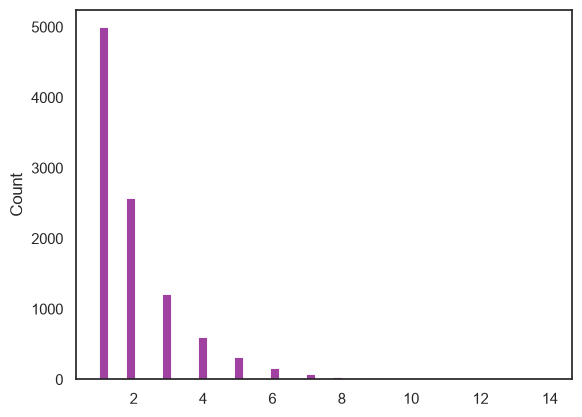

In [64]:
### Geométrica teórica
p =0.5

geom_teo = np.random.geometric(p, M)

sns.histplot(data=geom_teo, bins= 50, color='purple')


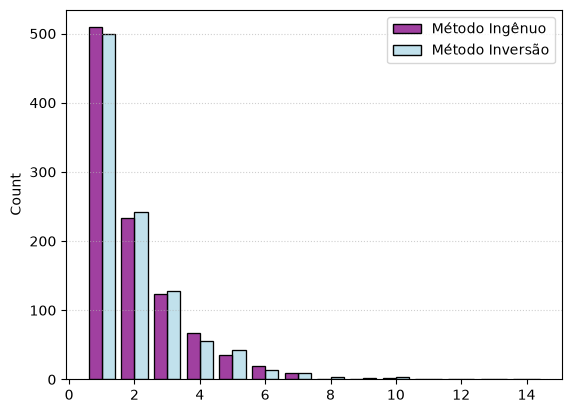

In [ ]:
dict = {'Método Ingênuo': teste,
        'Método Inversão': geom_teo}

df = pd.DataFrame(dict)

sns.histplot(df, multiple='dodge', shrink=0.8, discrete='True', palette={'Método Ingênuo': 'purple', 'Método Inversão': 'lightblue'})
plt.grid(axis='y', linestyle=':', alpha=0.6, )

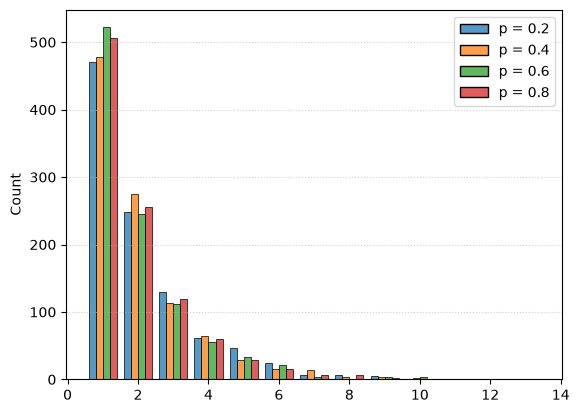

In [ ]:
teste1 = Geo_Ing(M, 0.2)
teste2 = Geo_Ing(M, 0.4)
teste3 = Geo_Ing(M, 0.6)
teste4 = Geo_Ing(M, 0.8)

dict2 = {'p = 0.2': teste1,
         'p = 0.4': teste2,
         'p = 0.6': teste3,
         'p = 0.8': teste4}

df2 = pd.DataFrame(dict2)

sns.histplot(df2, multiple='dodge', shrink=0.8, discrete='True')
plt.grid(axis='y', linestyle=':', alpha=0.6)


# Exercício 2

In [ ]:
### Método de inversão

def Geo_Inv (M, p):
    amostra_Inv = []
    for i in range(M):
        u = np.random.uniform()
        x = np.floor((np.log(1-u)) / (np.log(1-p))) + 1
        amostra_Inv.append(x)
    return amostra_Inv

[np.float64(1.0), np.float64(1.0), np.float64(9.0), np.float64(7.0), np.float64(4.0), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(1.0), np.float64(4.0), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(6.0), np.float64(2.0), np.float64(3.0), np.float64(1.0), np.float64(4.0), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(7.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(10.0), np.float64(7.0), np.float64(1.0), np.float64(5.0), np.float64(1.0), np.float64(3.0), np.float64(10.0), np.float64(3.0), np.float64(1.0), np.float64(1.0), np.float64(10.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(6.0), np.float64(4.0), np.float64(2.0), np.float64(3.0), np.float64(3.0), np.float64(2.0), np.float64(4.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(7.0), np.float64

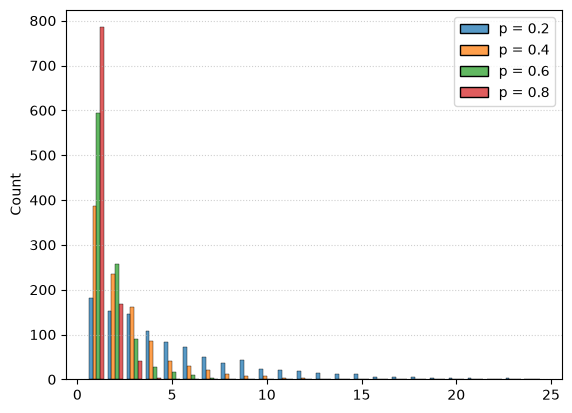

In [ ]:
teste5 = Geo_Inv(M, 0.2)
teste6 = Geo_Inv(M, 0.4)
teste7 = Geo_Inv(M, 0.6)
teste8 = Geo_Inv(M, 0.8)

dict3 = {'p = 0.2': teste5,
         'p = 0.4': teste6,
         'p = 0.6': teste7,
         'p = 0.8': teste8}

df3 = pd.DataFrame(dict3)

sns.histplot(df3, multiple='dodge', shrink=0.8, discrete='True')
plt.grid(axis='y', linestyle=':', alpha=0.6)

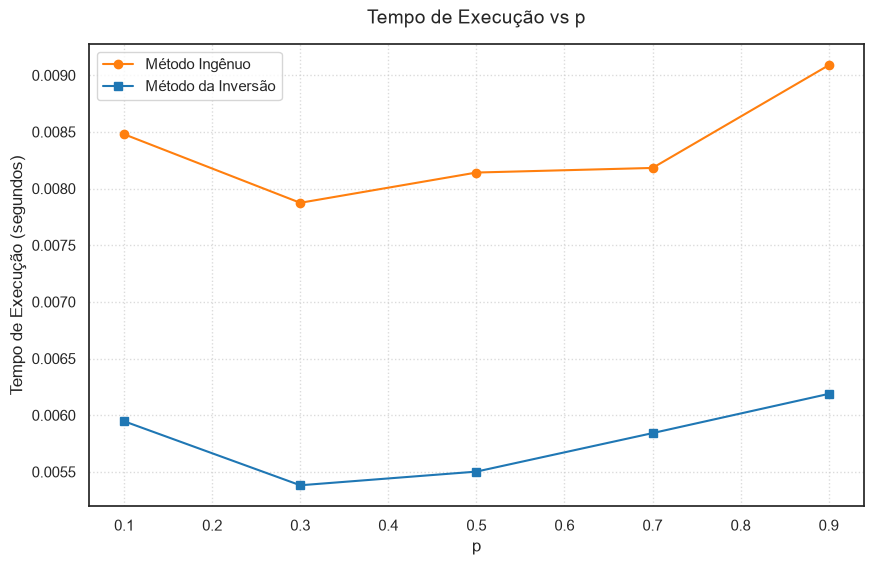

In [73]:
M = 1000
p = np.linspace(0.1, 0.9, 5)
repeticoes = 100 # Número de execuções para extrair uma média limpa

tempos_ing = []
tempos_inv = []

for i in p:
    t_ing = []
    t_inv = []
    
    # Laço interno para realizar múltiplas medições
    for _ in range(repeticoes):
        # Medindo o Método Ingênuo corretamente
        t_0 = time.time()
        Geo_Ing(M, i)
        t_ing.append(time.time() - t_0)
        
        # Medindo o Método da Inversão corretamente
        t_0 = time.time()
        Geo_Inv(M, i)
        t_inv.append(time.time() - t_0)
        
    tempos_ing.append(np.mean(t_ing))
    tempos_inv.append(np.mean(t_inv))

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

plt.plot(p, tempos_ing, marker='o', label='Método Ingênuo', color='#ff7f0e')
plt.plot(p, tempos_inv, marker='s', label='Método da Inversão', color='#1f77b4')

plt.title('Tempo de Execução vs p', fontsize=14, pad=15)
plt.xlabel('p', fontsize=12)
plt.ylabel('Tempo de Execução (segundos)', fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

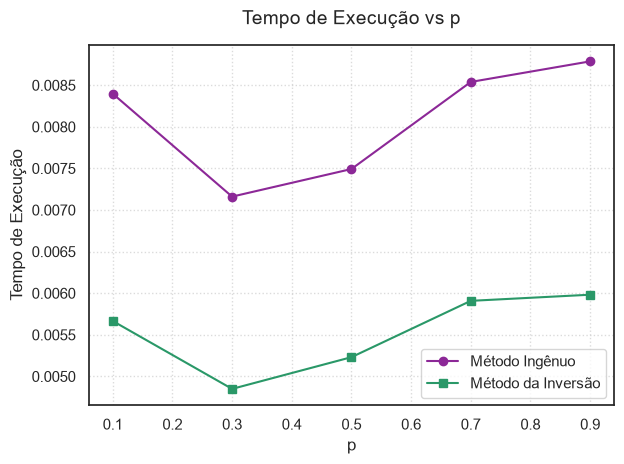

In [ ]:
p = np.linspace(0.1, 0.9, 5)

tempos_ing = []
tempos_inv = []

for i in p:
    t_ing = []
    t_inv = []

    for j in range(100):
        t_0 = time.time()
        Geo_Inv(M, i)
        t_inv.append(time.time() - t_0)
                
        t_1 = time.time()
        Geo_Ing(M, i)
        t_ing.append(time.time() - t_1)
            
    tempos_ing.append(np.mean(t_ing))
    tempos_inv.append(np.mean(t_inv))


plt.figure(figsize=(10, 6))
sns.set_theme(style="white")
plt.plot(p, tempos_ing, marker='o', label='Método Ingênuo', color="#8C2897")
plt.plot(p, tempos_inv, marker='s', label='Método da Inversão', color="#2a9868")
plt.title('Tempo de Execução vs p', fontsize=14, pad=15)
plt.xlabel('p', fontsize=12)
plt.ylabel('Tempo de Execução', fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Exercício 3

<Axes: ylabel='Count'>

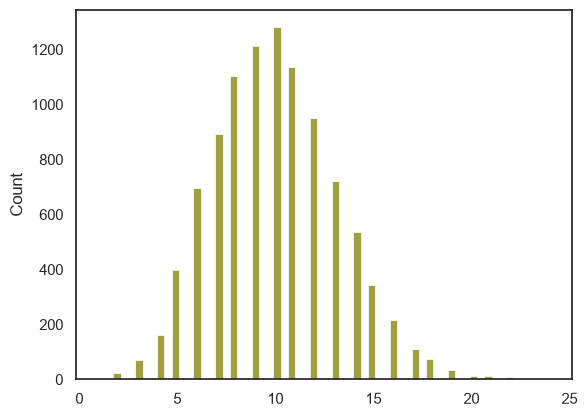

In [94]:
def poisson_recursiva(M, lamb):
    amostra = []
    
    for _ in range(M):
        u = np.random.uniform()
        i = 0
        p_i = np.exp(-lamb) 
        f = p_i            
        
        while u > f:
            p_imais1 = (lamb / (i + 1)) * p_i
            i += 1
            p_i = p_imais1
            f += p_i
            
        amostra.append(i)
        
    return amostra


lamb = 10
amostra_p = poisson_recursiva(M, lamb)

sns.histplot(amostra_p, color='olive')
